In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader

In [2]:
# check device GPU or CPU
if torch.cuda.is_available():
    device=torch.device="cuda"
else:
    device=torch.device="cpu"

print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Configuration (img_size, transform and normalize)
# Global Parameters
DATADIR='Modal_img'
IMG_SIZE=224
BATCH_SIZE=32
SEED=42
EPOCHS=50

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, shear=5, translate=(0.05, 0.05)), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.5, 2.0)), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset=datasets.ImageFolder(DATADIR,transform=train_transform)

CLASS_NAMES=full_dataset.classes
NUM_CLASSES=len(CLASS_NAMES)

# DEBUG: check whether all classes exists
REQUIRED_CLASSES=['no accident','minor','intermediate','major']
if not all (c in CLASS_NAMES for c in REQUIRED_CLASSES):
    raise ValueError(f"Dataset missing required folders. Found: {CLASS_NAMES}")
NO_ACCIDENT_IDX=CLASS_NAMES.index('no accident')

# DEBUG: Class Name and Total image loaded
print("\n=== Results for class name and total amount of images: ===")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class Names: {CLASS_NAMES}")
print(f"Total amount of images: {len(full_dataset)}")


=== Results for class name and total amount of images: ===
Number of classes: 4
Class Names: ['intermediate', 'major', 'minor', 'no accident']
Total amount of images: 1791


In [12]:
from model_definitions import TransferEfficient

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F
import os
import numpy as np
import time

# The usable training function
def train_cnn(model,train_loader,val_loader,num_classes, model_name, num_epochs,learning_rate,class_weights=None):
    model_dir = "models"
    os.makedirs(model_dir, exist_ok=True)
    model_save_path = os.path.join(model_dir, f"{model_name.lower().replace(' ','_')}_cnn_pytorch.pth")
    
    # Early Stopping Configuration
    PATIENCE=5
    best_f1=0.0
    epochs_no_improve=0
    
    # Reduce LR On Plateau
    LR_FACTOR=0.5
    LR_PATIENCE=4
    lr_epochs_no_improve=0
    
    # Define loss function
    if class_weights is not None:
        criterion=nn.CrossEntropyLoss(weight=class_weights)
        print(f"  (Using Weighted Loss: {class_weights.tolist()})")
    else:
        criterion=nn.CrossEntropyLoss()
    # Define Optimizer
    optimizer=optim.Adam(model.parameters(),lr=learning_rate,weight_decay=1e-5)

    train_losses=[]
    val_losses=[]
    val_accuracies=[]
    train_accuracies=[]
    val_f1_scores=[]
    val_auc_scores=[]

    # LOG: Display Model Training Process
    print(f"\n=== Starting CNN Model Training for {model_name} (Classes: {num_classes}):===\n")
    print(f"    (Epochs: {num_epochs}, Learning Rate: {learning_rate})")

    for epoch in range(num_epochs):
        start_time=time.time()
        # Training phase (Training mode)
        model.train()
        running_loss=0.0
        correct_train, total_train =0,0
        for inputs,labels in train_loader:
            inputs,labels=inputs.to(device),labels.to(device)
            
            optimizer.zero_grad()
            # forward pass
            outputs=model(inputs)
            loss=criterion(outputs,labels)
            # backward pass to calc gradient
            loss.backward()
            optimizer.step()
            
            running_loss+=loss.item()
            _,predicted=torch.max(outputs.data,1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
        avg_train_loss=running_loss/len(train_loader)
        train_accuracy=100*correct_train/total_train
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)
        
        # Validation Phase (Evaluation mode)
        model.eval()
        all_labels=[]
        all_predictions=[]
        all_scores=[]
        
        correct=0
        total=0
        val_running_loss=0.0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels=inputs.to(device), labels.to(device)
                outputs=model(inputs)
                val_loss = criterion(outputs, labels)
                val_running_loss += val_loss.item()
                
                # Get the logits
                all_scores.extend(outputs.cpu().numpy())
                _,predicted=torch.max(outputs.data,1)
                
                # Collected labels and predictions
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
                
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            
        val_accuracy =100*correct/total
        val_accuracies.append(val_accuracy)
        avg_val_loss = val_running_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        # F1 score
        macro_f1=f1_score(all_labels, all_predictions,average="macro",zero_division=0)
        val_f1_scores.append(macro_f1)
        
        # AUC scores
        softmax_scores = F.softmax(torch.tensor(all_scores), dim=1).numpy()
        
        try:
            if num_classes == 2:
                # 1. BINARY CLASSIFICATION LOGIC
                # y_true must be 1D (all_labels). 
                # y_score must be 1D (probabilities for the POSITIVE class only: index 1).
                # We do NOT use multi_class='ovr' or binarized labels here.
                macro_auc = roc_auc_score(all_labels, softmax_scores[:, 1])

            else:
                macro_auc = 0.0 
                
        except ValueError as e:
            macro_auc = 0.0 
            print(f"Error: Could not compute AUC. {e}")
        
        val_auc_scores.append(macro_auc)
        
        # Confusion Matrix
        confusion=confusion_matrix(all_labels, all_predictions)
        
        end_time=time.time()
        epoch_time=end_time-start_time
    
        # LOG: Display results for each epoch
        print(f"[Epoch {epoch+1:03}/{num_epochs}] " 
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Train Acc: {train_accuracy:.2f}% | "
              f"Val Acc: {val_accuracy:.2f}% | "
              f"Val F1: {macro_f1:.4f} | "
              f"Val AUC: {macro_auc:.4f} | "
              f"Time: {epoch_time:.2f}s")

        # Model Checkpoint
        if macro_f1 > best_f1:
            best_f1=macro_f1
            epochs_no_improve=0
            lr_epochs_no_improve=0
            torch.save(model.state_dict(), model_save_path)
            print(f"\n{model_name} Model weights successfully saved to: {model_save_path}")
            best_confusion = confusion 
            best_all_labels = all_labels 
            best_all_predictions = all_predictions
            best_softmax_scores = softmax_scores
        else:
            epochs_no_improve +=1
            lr_epochs_no_improve+=1
             # Early stopping
            if epochs_no_improve >= PATIENCE:
                print(f"\n! EARLY STOPPING triggered at epoch {epoch+1}. Validation F1 score has not improved for {PATIENCE} epochs.")
                break
                
            # Reduce LR on PlateEU
            if lr_epochs_no_improve >= LR_PATIENCE:
                old_lr=optimizer.param_groups[0]['lr']
                new_lr=old_lr * LR_FACTOR
                if new_lr < 1e-6:
                    new_lr=1e-6
                if new_lr<old_lr:
                    optimizer.param_groups[0]['lr']=new_lr
                    print(f"\n ReduceLROnPlateau: Reducing learning rate from {old_lr:.6f} to {new_lr:.6f}")
                    lr_epochs_no_improve = 0 
        
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
    print("\n== Training Done ==")
    
    if os.path.exists(model_save_path):
        model.load_state_dict(torch.load(model_save_path))
        print(f"\nFinal: Loaded best model weights (F1: {best_f1:.4f}) from {model_save_path}")
    
    return model,train_losses,val_accuracies,macro_f1,best_confusion,best_all_labels,best_all_predictions,best_softmax_scores,train_accuracies,val_losses

In [ ]:
from torch.utils.data import WeightedRandomSampler
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset
# Global Parameter for two-stage training
INITIAL_LR=0.0001
FINE_TUNE_LR=0.00001

# Model A: Binary Classifier (Accident vs. No accident)
print("\n=== Starting Model A: Binary Classifier ===\n")

# Return 0 for no accident 1 for accident
def binary_relabel(label_index):
    if label_index == NO_ACCIDENT_IDX: 
        return 0
    else:
        return 1

full_dataset_for_splitting = datasets.ImageFolder(DATADIR, transform=val_test_transform, target_transform=binary_relabel)
BINARY_NUM_CLASSES=2

# Split data (80:20)
all_targets = np.array([full_dataset_for_splitting[i][1] for i in range(len(full_dataset_for_splitting))])
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_index, val_full_index = next(splitter.split(np.zeros(len(full_dataset_for_splitting)), all_targets))
val_full_targets = all_targets[val_full_index]
val_no_accident_indices = val_full_index[val_full_targets == 0]
val_accident_indices = val_full_index[val_full_targets == 1]
MINORITY_COUNT = len(val_no_accident_indices)
np.random.shuffle(val_accident_indices)
balanced_accident_indices = val_accident_indices[:MINORITY_COUNT]
balanced_val_index = np.concatenate([val_no_accident_indices, balanced_accident_indices])
binary_train_dataset = Subset(
    datasets.ImageFolder(DATADIR, transform=train_transform, target_transform=binary_relabel),
    train_index
)
binary_val_dataset = Subset(
    datasets.ImageFolder(DATADIR, transform=val_test_transform, target_transform=binary_relabel),
    balanced_val_index
)
new_val_targets = np.array([binary_val_dataset[i][1] for i in range(len(binary_val_dataset))])
val_class_counts = np.bincount(new_val_targets)

# Implement Weighted Random Sampler
train_targets=[sample[1] for sample in binary_train_dataset]
class_counts=np.bincount(train_targets)
weights_per_class=1. / class_counts
sample_weights=[weights_per_class[target] for target in train_targets]

sampler=WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

binary_train_loader=DataLoader(binary_train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
binary_val_loader=DataLoader(binary_val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Start to train
binary_model=TransferEfficient(BINARY_NUM_CLASSES).to(device)
# Stage 1: Frozen Training
print(f"\n=== STARTING ACCIDENT MODEL FROZEN TRAINING ({EPOCHS} EPOCHS and Higher Learning rate) ===")
binary_model, _, _,_,_,_,_,_,_,_=train_cnn(binary_model,binary_train_loader,binary_val_loader,BINARY_NUM_CLASSES,"Accident_TransferEfficient_Frozen", num_epochs=EPOCHS, learning_rate=INITIAL_LR)
# Stage 2: Unfreeze Training 
binary_model.unfreeze_backbone()
print(f"\n=== STARTING ACCIDENT MODEL UNFREEZE TRAINING ({EPOCHS} EPOCHS and Lower Learning rate) ===")
binary_model, binary_losses, binary_accuracies,binary_f1_score,binary_cm,binary_labels,binary_predictions, binary_auc,train_accuracies,val_losses=train_cnn(binary_model,binary_train_loader,binary_val_loader,BINARY_NUM_CLASSES,"Accident_TransferEfficient_Unfreeze", num_epochs=EPOCHS, learning_rate=FINE_TUNE_LR)


=== Starting Model A: Binary Classifier ===


=== STARTING ACCIDENT MODEL FROZEN TRAINING (50 EPOCHS and Higher Learning rate) ===

=== Starting CNN Model Training for Accident_TransferEfficient_Frozen (Classes: 2):===

    (Epochs: 50, Learning Rate: 0.0001)


C:\Users\USER\AppData\Local\Temp\ipykernel_15400\2763614864.py:107: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:281.)
  softmax_scores = F.softmax(torch.tensor(all_scores), dim=1).numpy()


[Epoch 001/50] Train Loss: 0.5892 | Train Acc: 78.21% | Val Acc: 87.20% | Val F1: 0.8706 | Val AUC: 0.9793 | Time: 33.19s

Accident_TransferEfficient_Frozen Model weights successfully saved to: accident_transferefficient_frozen_cnn_pytorch.pth
[Epoch 002/50] Train Loss: 0.4020 | Train Acc: 87.85% | Val Acc: 81.10% | Val F1: 0.8057 | Val AUC: 0.9792 | Time: 37.25s
[Epoch 003/50] Train Loss: 0.3070 | Train Acc: 88.76% | Val Acc: 84.76% | Val F1: 0.8445 | Val AUC: 0.9830 | Time: 32.77s
[Epoch 004/50] Train Loss: 0.2873 | Train Acc: 89.32% | Val Acc: 85.37% | Val F1: 0.8510 | Val AUC: 0.9845 | Time: 30.87s
[Epoch 005/50] Train Loss: 0.2860 | Train Acc: 88.34% | Val Acc: 94.51% | Val F1: 0.9450 | Val AUC: 0.9881 | Time: 35.63s

Accident_TransferEfficient_Frozen Model weights successfully saved to: accident_transferefficient_frozen_cnn_pytorch.pth
[Epoch 006/50] Train Loss: 0.2463 | Train Acc: 90.71% | Val Acc: 92.68% | Val F1: 0.9266 | Val AUC: 0.9871 | Time: 34.25s
[Epoch 007/50] Train Los

C:\Users\USER\AppData\Local\Temp\ipykernel_15400\2763614864.py:177: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_path))


[Epoch 001/50] Train Loss: 0.2259 | Train Acc: 90.85% | Val Acc: 90.24% | Val F1: 0.9017 | Val AUC: 0.9923 | Time: 81.73s

Accident_TransferEfficient_Unfreeze Model weights successfully saved to: accident_transferefficient_unfreeze_cnn_pytorch.pth
[Epoch 002/50] Train Loss: 0.1689 | Train Acc: 94.13% | Val Acc: 95.73% | Val F1: 0.9573 | Val AUC: 0.9943 | Time: 82.70s

Accident_TransferEfficient_Unfreeze Model weights successfully saved to: accident_transferefficient_unfreeze_cnn_pytorch.pth
[Epoch 003/50] Train Loss: 0.1810 | Train Acc: 93.02% | Val Acc: 96.34% | Val F1: 0.9634 | Val AUC: 0.9963 | Time: 70.98s

Accident_TransferEfficient_Unfreeze Model weights successfully saved to: accident_transferefficient_unfreeze_cnn_pytorch.pth
[Epoch 004/50] Train Loss: 0.1640 | Train Acc: 94.62% | Val Acc: 96.95% | Val F1: 0.9695 | Val AUC: 0.9967 | Time: 73.90s

Accident_TransferEfficient_Unfreeze Model weights successfully saved to: accident_transferefficient_unfreeze_cnn_pytorch.pth
[Epoch 0

C:\Users\USER\AppData\Local\Temp\ipykernel_15400\2763614864.py:177: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_path))


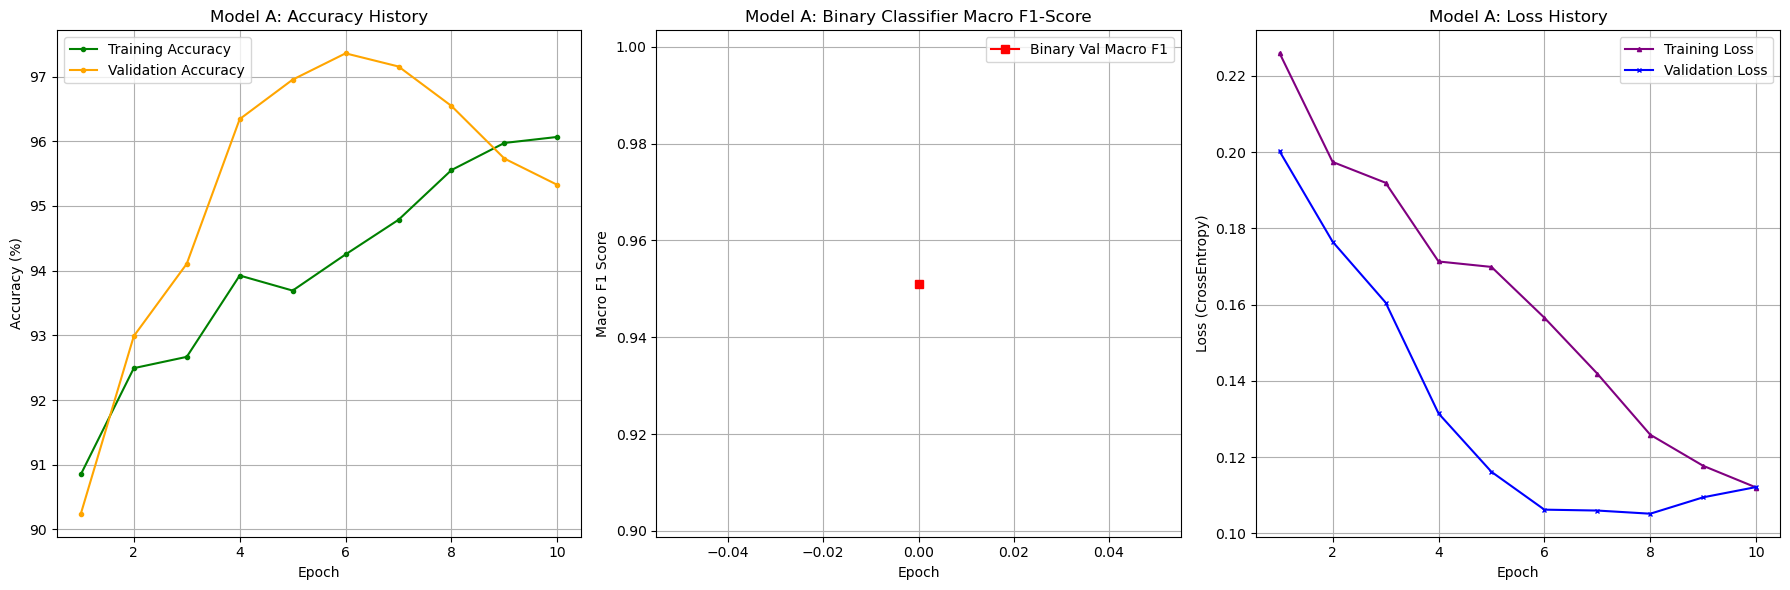

In [7]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd

def smooth_data(data, window=3):
    # Convert list to pandas Series, apply rolling mean, and convert back to list
    return pd.Series(data).rolling(window=window, min_periods=1).mean().tolist()

epochs_run = range(1, len(binary_losses) + 1)

smooth_train_acc = smooth_data(train_accuracies)
smooth_val_acc = smooth_data(binary_accuracies)
smooth_train_loss = smooth_data(binary_losses)
smooth_val_loss = smooth_data(val_losses)
smooth_f1 = smooth_data(binary_f1_score)

# --- Visualization For Model A (2x2 Layout) ---
plt.figure(figsize=(18, 6)) # Adjusted for a 3-plot layout

# 1. ACCURACY PLOT: Training vs. Validation
plt.subplot(1, 3, 1) 
plt.plot(epochs_run, smooth_train_acc, label='Training Accuracy', color='green', marker='o', markersize=3)
plt.plot(epochs_run, smooth_val_acc, label='Validation Accuracy', color='orange', marker='o', markersize=3)
plt.title('Model A: Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

# 2. F1-SCORE PLOT (Validation Only)
plt.subplot(1, 3, 2)
plt.plot(binary_f1_score, label='Binary Val Macro F1', color='red', marker='s')
plt.title('Model A: Binary Classifier Macro F1-Score')
plt.xlabel('Epoch')
plt.ylabel('Macro F1 Score')
plt.grid(True)
plt.legend()

# 3. LOSS PLOT: Training vs. Validation
plt.subplot(1, 3, 3) 
plt.plot(epochs_run, smooth_train_loss, label='Training Loss', color='purple', marker='^', markersize=3)
plt.plot(epochs_run, smooth_val_loss, label='Validation Loss', color='blue', marker='x', markersize=3) 
plt.title('Model A: Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss (CrossEntropy)')
plt.grid(True)
plt.legend()

plt.tight_layout() # Adjusts plots to fit nicely
plt.show() # Display the final combined figure

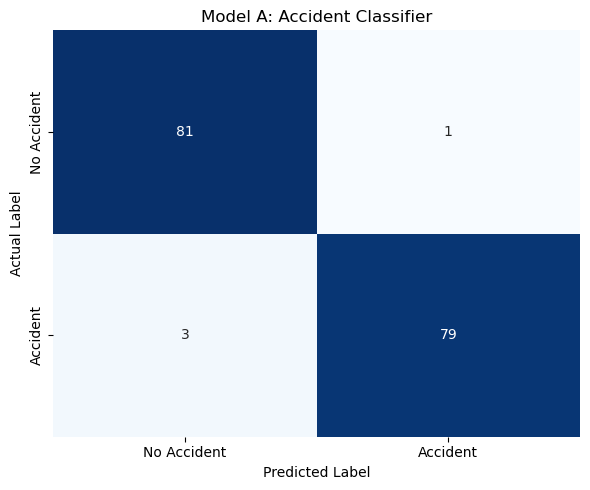

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(figsize=(6, 5))  

# --- Model A Heatmap ---
sns.heatmap(binary_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Accident', 'Accident'],
            yticklabels=['No Accident', 'Accident'],
            cbar=False, ax=axes)
axes.set_title("Model A: Accident Classifier")
axes.set_ylabel("Actual Label")
axes.set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

In [9]:
# Classification Report
from tabulate import tabulate
from sklearn.metrics import classification_report

# Model A 
print("\n=== Classification Report: Model A (Accident Classifier) ===\n")
binary_target_names=['No Accident','Accident']
binary_report=classification_report(binary_labels, binary_predictions,target_names=binary_target_names,output_dict=True,zero_division=0)
binary_rows = []
for label, metrics in binary_report.items():
    if isinstance(metrics, dict): 
        binary_rows.append([label,
                     metrics['precision'],
                     metrics['recall'],
                     metrics['f1-score'],
                     metrics['support']])
    else: 
        binary_rows.append([label, metrics, '', '', ''])
print(tabulate(binary_rows,
               headers=['Class', 'Precision', 'Recall', 'F1-Score', 'Support'],
               tablefmt='grid'))


=== Classification Report: Model A (Accident Classifier) ===

+--------------+-------------+--------------------+--------------------+-----------+
| Class        |   Precision | Recall             | F1-Score           | Support   |
+==============+=============+====================+====================+===========+
| No Accident  |    0.964286 | 0.9878048780487805 | 0.9759036144578314 | 82.0      |
+--------------+-------------+--------------------+--------------------+-----------+
| Accident     |    0.9875   | 0.9634146341463414 | 0.9753086419753086 | 82.0      |
+--------------+-------------+--------------------+--------------------+-----------+
| accuracy     |    0.97561  |                    |                    |           |
+--------------+-------------+--------------------+--------------------+-----------+
| macro avg    |    0.975893 | 0.975609756097561  | 0.97560612821657   | 164.0     |
+--------------+-------------+--------------------+--------------------+-----------+
| 

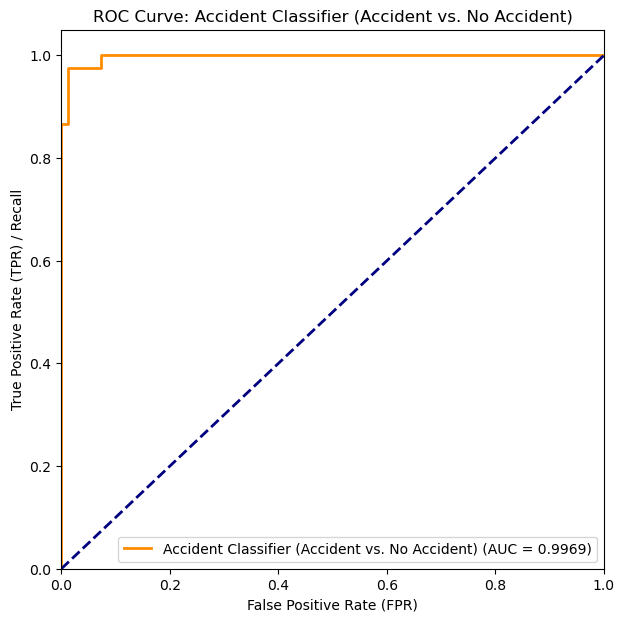

In [10]:
# AUC Curve
from sklearn.metrics import roc_curve, auc

def plot_binary_roc(y_true, y_scores, title):
    scores_positive = y_scores[:, 1]
    fpr, tpr, _ = roc_curve(y_true, scores_positive, pos_label=1)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 7))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'{title} (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR) / Recall')
    plt.title(f'ROC Curve: {title}')
    plt.legend(loc="lower right")
    plt.show()
    plt.close()
    
# Plot Accident Classifier ROC Curves 
plot_binary_roc(
    y_true=np.array(binary_labels), 
    y_scores=binary_auc, 
    title="Accident Classifier (Accident vs. No Accident)"
)

C:\Users\USER\AppData\Local\Temp\ipykernel_15400\2570916498.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev

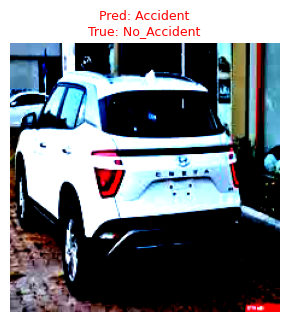

In [ ]:
import random

class_names = ['No_Accident', 'Accident']
model_path = "accident_transferefficient_unfreeze_cnn_pytorch.pth" 
model = TransferEfficient(BINARY_NUM_CLASSES) 
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval() 

images, labels = next(iter(binary_val_loader)) 
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

true_ids = labels.cpu().numpy()
pred_ids = predicted.cpu().numpy()

error_indices = np.where(pred_ids != true_ids)[0] 

PLOT_COUNT = 12
if len(error_indices) > PLOT_COUNT:
    plot_indices = random.sample(list(error_indices), PLOT_COUNT)
else:
    plot_indices = error_indices

plt.figure(figsize=(12, 9))
if len(plot_indices) == 0:
    print("No misclassified images found in this batch!")
else:
    for i, idx in enumerate(plot_indices):
        ax = plt.subplot(3, 4, i + 1)
        
        img = images[idx].cpu().numpy().transpose((1, 2, 0)) 
        
        
        true_label = class_names[true_ids[idx]] 
        pred_label = class_names[pred_ids[idx]]
        color = "red" 
        
        plt.imshow(img)
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()